In [5]:
# ── Clean Assignment 7 plotting file ──────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import os
import sys
import json
import copy
import pathlib
import importlib.util

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.path as _mpath
import geopandas as gpd

# ── Matplotlib deepcopy patch ────────────────────────────────────────────────
def _fixed_path_deepcopy(self, memo):
    cls = type(self)
    verts = copy.deepcopy(self.vertices, memo)
    codes = copy.deepcopy(self.codes, memo) if self.codes is not None else None
    new = cls.__new__(cls)
    new.__init__(verts, codes)
    return new

_mpath.Path.__deepcopy__ = _fixed_path_deepcopy

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

# ── Paths ────────────────────────────────────────────────────────────────────
try:
    NOTEBOOK_DIR = os.path.dirname(os.path.abspath(__vsc_ipynb_file__))
except NameError:
    NOTEBOOK_DIR = os.path.abspath(".")

JUSTICE_ROOT = os.path.normpath(os.path.join(NOTEBOOK_DIR, "../JUSTICE-main"))
RESULTS_DIR = os.path.normpath(os.path.join(NOTEBOOK_DIR, "results_refs"))
PLOTS_DIR = os.path.join(NOTEBOOK_DIR, "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)

if JUSTICE_ROOT not in sys.path:
    sys.path.insert(0, JUSTICE_ROOT)

os.chdir(JUSTICE_ROOT)

# ── JUSTICE imports ──────────────────────────────────────────────────────────
from justice.model import JUSTICE
from justice.util.data_loader import DataLoader
from justice.util.enumerations import Abatement, DamageFunction, Economy, WelfareFunction
from justice.util.emission_control_constraint import EmissionControlConstraint
from justice.util.model_time import TimeHorizon
from justice.abatement.abatement_enerdata import AbatementEnerdata
from justice.objectives.objective_functions import fraction_of_ensemble_above_threshold
from solvers.emodps.rbf import RBF

# ── Settings ─────────────────────────────────────────────────────────────────
CONFIG_PATH = os.path.join(NOTEBOOK_DIR, "../config/config_student.json")

BACKSTOP_COST = 300
DECLINE_RATE = 0.101
N_ENSEMBLE = 10
THRESHOLD = 2.0

OBJECTIVE_COLS = [
    "welfare",
    "fraction_above_threshold",
    "welfare_loss_damage",
    "welfare_loss_abatement",
]

with open(CONFIG_PATH) as fh:
    cfg = json.load(fh)

time_horizon = TimeHorizon(
    start_year=cfg["start_year"],
    end_year=cfg["end_year"],
    data_timestep=cfg["data_timestep"],
    timestep=cfg["timestep"],
)

years = np.asarray(time_horizon.model_time_horizon).astype(int)
N_TIMESTEPS = len(years)
REGION_LIST = list(DataLoader().REGION_LIST)
N_REGIONS = len(REGION_LIST)
N_INPUTS_RBF = cfg["n_inputs"]
N_RBFS = cfg["n_inputs"] + 2
SCENARIO = cfg["reference_ssp_rcp_scenario_index"]
EC_START_TS = time_horizon.year_to_timestep(
    year=cfg["emission_control_start_year"],
    timestep=cfg["timestep"],
)

MAX_TEMP, MIN_TEMP = 16.0, 0.0
MAX_DIFF, MIN_DIFF = 2.0, 0.0

print(f"JUSTICE root: {JUSTICE_ROOT}")
print(f"Results dir : {RESULTS_DIR}")
print(f"Plots dir   : {PLOTS_DIR}")

JUSTICE root: c:\Users\marij\OneDrive\Documenten\Master-EPA\Model-Based-DM\epa141a_01\JUSTICE-main
Results dir : c:\Users\marij\OneDrive\Documenten\Master-EPA\Model-Based-DM\epa141a_01\assignments_ema\results_refs
Plots dir   : c:\Users\marij\OneDrive\Documenten\Master-EPA\Model-Based-DM\epa141a_01\assignments_ema\plots


In [6]:
# ── Helpers ──────────────────────────────────────────────────────────────────
def load_reference_set(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Could not find: {path}")

    ref = pd.read_csv(path)
    ref.columns = ref.columns.str.strip().str.replace(" ", "_")
    return ref


def find_col(ref, possible_cols):
    for col in possible_cols:
        if col in ref.columns:
            return col
    raise KeyError(
        "None of these columns found:\n"
        + ", ".join(possible_cols)
        + "\nAvailable columns are:\n"
        + ", ".join(ref.columns)
    )


def find_threshold_col(ref):
    return find_col(ref, [
        "fraction_above_threshold",
        "fraction_above_1p5C",
        "fraction_above_2C",
        "fraction_of_ensemble_above_threshold",
    ])


def get_anchor_indices(ref):
    return {
        "Lowest welfare loss": ref["welfare"].idxmin(),
        "Lowest threshold exceedance": ref[find_threshold_col(ref)].idxmin(),
        "Best damage objective": ref["welfare_loss_damage"].idxmax(),
        "Best abatement objective": ref["welfare_loss_abatement"].idxmax(),
    }


def find_gbr_index():
    region_lower = [str(r).lower() for r in REGION_LIST]
    for cand in ["gbr", "uk", "united kingdom", "britain"]:
        for i, region in enumerate(region_lower):
            if cand in region:
                return i

    print(REGION_LIST)
    raise ValueError("Could not find GBR/UK region in REGION_LIST.")


def mean_global_temperature(datasets):
    temp = np.asarray(datasets["global_temperature"])
    return np.nanmean(temp, axis=1) if temp.ndim == 2 else temp


def global_emissions(datasets):
    emissions = np.asarray(datasets["emissions"])
    if emissions.ndim == 3:
        emissions = np.nanmean(emissions, axis=2)
    return emissions.sum(axis=0)


def mean_global_ecr(ecr):
    ecr = np.asarray(ecr)
    if ecr.ndim == 3:
        ecr = np.nanmean(ecr, axis=2)
    return np.nanmean(ecr, axis=0)


def global_welfare(datasets):
    return np.asarray(datasets["temporally_disaggregated_welfare"])


def global_avg_consumption_per_capita(datasets):
    cpc = np.asarray(datasets["consumption_per_capita"])
    if cpc.ndim != 3:
        raise ValueError(f"Unexpected consumption_per_capita shape: {cpc.shape}")
    return np.nanmean(cpc, axis=(0, 2))


def gbr_consumption_per_capita(datasets):
    gbr_idx = find_gbr_index()
    cpc = np.asarray(datasets["consumption_per_capita"])
    if cpc.ndim != 3:
        raise ValueError(f"Unexpected consumption_per_capita shape: {cpc.shape}")
    return np.nanmean(cpc[gbr_idx, :, :], axis=1)


def run_policy_with_backstop(
    policy_row,
    backstop_cost=BACKSTOP_COST,
    backstop_cost_decline_rate_per_5_year=DECLINE_RATE,
    n_ensemble=N_ENSEMBLE,
    threshold=THRESHOLD,
):
    rbf = RBF(n_rbfs=N_RBFS, n_inputs=N_INPUTS_RBF, n_outputs=N_REGIONS)
    c_shape, r_shape, w_shape = rbf.get_shape()

    centers = np.array([policy_row[f"center_{i}"] for i in range(c_shape[0])])
    radii = np.array([policy_row[f"radii_{i}"] for i in range(r_shape[0])])
    weights = np.array([policy_row[f"weights_{i}"] for i in range(w_shape[0])])
    rbf.set_decision_vars(np.concatenate([centers, radii, weights]))

    constraint = EmissionControlConstraint(
        max_annual_growth_rate=0.04,
        emission_control_start_timestep=EC_START_TS,
        min_emission_control_rate=0.01,
    )

    ensemble_indices = list(np.linspace(1, 1000, n_ensemble, dtype=int))

    # JUSTICE is a singleton. This is required when changing ensemble/settings.
    JUSTICE.hard_reset()

    model = JUSTICE(
        scenario=SCENARIO,
        climate_ensembles=ensemble_indices,
        economy_type=Economy.NEOCLASSICAL,
        damage_function_type=DamageFunction.KALKUHL,
        abatement_type=Abatement.ENERDATA,
        social_welfare_function_type=WelfareFunction.UTILITARIAN.value[0],
    )

    model.abatement = AbatementEnerdata(
        input_dataset=model.data_loader,
        time_horizon=model.time_horizon,
        scenario=model.scenario,
        backstop_cost=backstop_cost,
        backstop_cost_decline_rate_per_5_year=backstop_cost_decline_rate_per_5_year,
    )

    no_ens = model.no_of_ensembles
    ecr = np.zeros((N_REGIONS, N_TIMESTEPS, no_ens))
    constrained_ecr = np.zeros_like(ecr)

    prev_temp = np.zeros(no_ens)
    diff = np.zeros(no_ens)

    for t in range(N_TIMESTEPS):
        constrained_ecr[:, t, :] = constraint.constrain_emission_control_rate(
            ecr[:, t, :],
            t,
            allow_fallback=False,
        )

        model.stepwise_run(
            emission_control_rate=constrained_ecr[:, t, :],
            timestep=t,
            endogenous_savings_rate=True,
        )

        data_t = model.stepwise_evaluate(timestep=t)
        temp = data_t["global_temperature"][t, :]

        if t % 5 == 0:
            diff = temp - prev_temp
            prev_temp = temp

        scaled_temp = (temp - MIN_TEMP) / (MAX_TEMP - MIN_TEMP)
        scaled_diff = (diff - MIN_DIFF) / (MAX_DIFF - MIN_DIFF)

        if t < N_TIMESTEPS - 1:
            ecr[:, t + 1, :] = rbf.apply_rbfs(np.array([scaled_temp, scaled_diff]))

    datasets = model.evaluate()

    temp_year_idx = time_horizon.year_to_timestep(
        year=cfg["temperature_year_of_interest"],
        timestep=cfg["timestep"],
    )

    frac_above = fraction_of_ensemble_above_threshold(
        temperature=datasets["global_temperature"],
        temperature_year_index=temp_year_idx,
        threshold=float(threshold),
    )

    return {
        "ecr": np.nanmean(constrained_ecr, axis=2),
        "datasets": datasets,
        "fraction_above_threshold": float(frac_above),
    }


def run_lowest_threshold_policy(path):
    ref = load_reference_set(path)
    idx = ref[find_threshold_col(ref)].idxmin()
    return run_policy_with_backstop(ref.loc[idx]), ref.loc[idx]


def run_four_policies(path):
    ref = load_reference_set(path)
    results = {}

    for label, idx in get_anchor_indices(ref).items():
        print(f"Running {os.path.basename(path)} | {label}")
        results[label] = run_policy_with_backstop(ref.loc[idx])

    return results

In [3]:
# ── Reference sets ────────────────────────────────────────────────────────────
ref_temp_two = {
    "Prioritarian 2C": os.path.join(RESULTS_DIR, "reference_set_prio_2.csv"),
    "Utilitarian main bs300": os.path.join(RESULTS_DIR, "reference_set_utilitarian_main_bs300.csv"),
}

ref_emissions = {
    "Prio 1.5C": os.path.join(RESULTS_DIR, "reference_set_prio_1_5.csv"),
    "Utilitarian 1.5C green": os.path.join(RESULTS_DIR, "reference_set_utilitarian_1_5_green.csv"),
    "Prio 2C": os.path.join(RESULTS_DIR, "reference_set_prio_2.csv"),
    "Utilitarian main bs": os.path.join(RESULTS_DIR, "reference_set_utilitarian_main_bs300.csv"),
}

ref_ecr_by_set = {
    "Prio 1.5C": os.path.join(RESULTS_DIR, "reference_set_prio_1_5.csv"),
    "Utilitarian 1.5C green": os.path.join(RESULTS_DIR, "reference_set_utilitarian_1_5_green.csv"),
    "Prio 2C": os.path.join(RESULTS_DIR, "reference_set_prio_2.csv"),
    "Utilitarian bs200 dec10": os.path.join(RESULTS_DIR, "reference_set_utilitarian_bs200_dec10.csv"),
}

util_bs300_path = os.path.join(RESULTS_DIR, "reference_set_utilitarian_main_bs300.csv")

In [4]:
# ── Run policies once and cache outputs ───────────────────────────────────────
lowest_threshold_results = {}

for label, path in ref_temp_two.items():
    print(f"Running lowest-threshold policy: {label}")
    result, row = run_lowest_threshold_policy(path)
    lowest_threshold_results[label] = result
    print(row[OBJECTIVE_COLS])
    print("rerun fraction above threshold:", result["fraction_above_threshold"])

util_four = run_four_policies(util_bs300_path)

lowest_threshold_emissions_results = {}

for label, path in ref_emissions.items():
    print(f"Running lowest-threshold emissions policy: {label}")
    result, _ = run_lowest_threshold_policy(path)
    lowest_threshold_emissions_results[label] = result

ecr_by_refset_results = {}

for label, path in ref_ecr_by_set.items():
    ecr_by_refset_results[label] = run_four_policies(path)

Running lowest-threshold policy: Prioritarian 2C
welfare                       100.991939
fraction_above_threshold        0.200000
welfare_loss_damage          3952.001897
welfare_loss_abatement      10868.264168
Name: 0, dtype: float64
rerun fraction above threshold: 0.3
Running lowest-threshold policy: Utilitarian main bs300
welfare                       103.651416
fraction_above_threshold        0.200000
welfare_loss_damage          3650.959784
welfare_loss_abatement      10782.315600
Name: 3, dtype: float64
rerun fraction above threshold: 0.2
Running reference_set_utilitarian_main_bs300.csv | Lowest welfare loss
Running reference_set_utilitarian_main_bs300.csv | Lowest threshold exceedance
Running reference_set_utilitarian_main_bs300.csv | Best damage objective
Running reference_set_utilitarian_main_bs300.csv | Best abatement objective
Running lowest-threshold emissions policy: Prio 1.5C
Running lowest-threshold emissions policy: Utilitarian 1.5C green
Running lowest-threshold emis

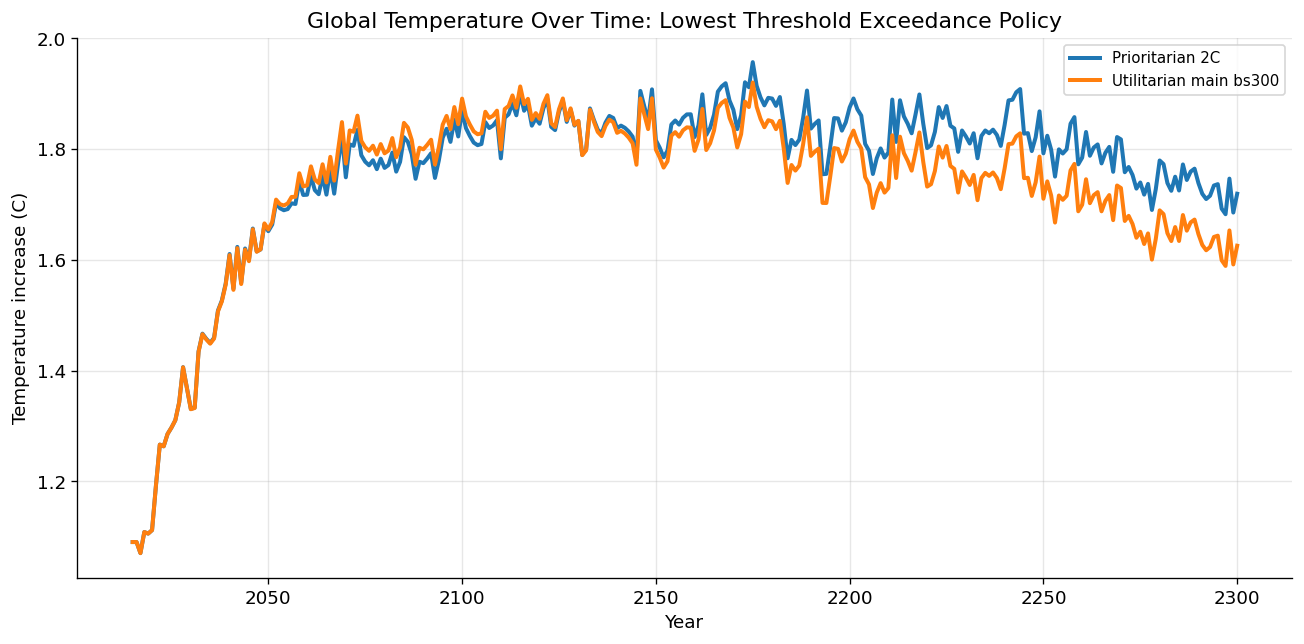

In [5]:
# ── Plot 1: global temperature, lowest threshold, two reference sets ──────────
fig, ax = plt.subplots(figsize=(11, 5.5))

for label, result in lowest_threshold_results.items():
    ax.plot(years, mean_global_temperature(result["datasets"]), linewidth=2.4, label=label)

ax.set_title("Global Temperature Over Time: Lowest Threshold Exceedance Policy")
ax.set_xlabel("Year")
ax.set_ylabel("Temperature increase (C)")
ax.grid(alpha=0.3)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "global_temperature_lowest_threshold_two_refsets.png"), dpi=150)
plt.show()

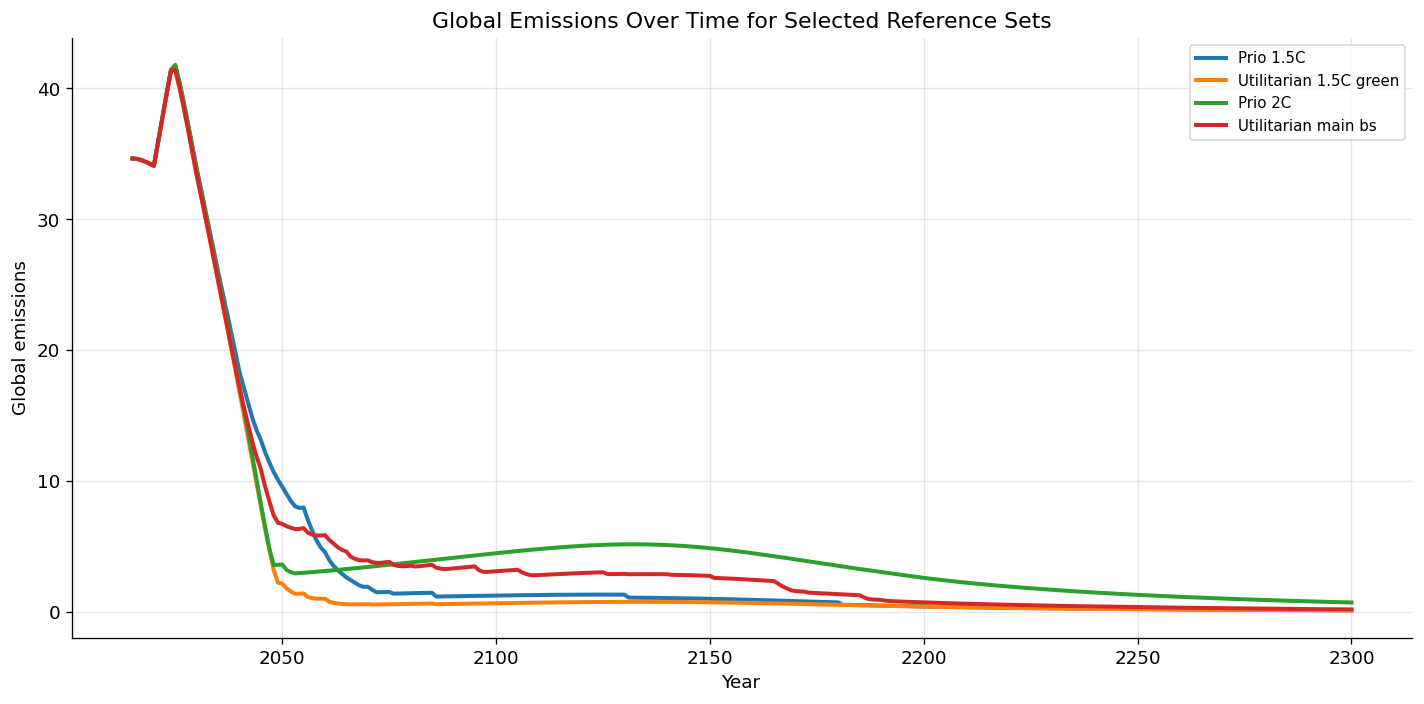

In [6]:
# ── Plot 2: global emissions, lowest threshold, selected reference sets ───────
fig, ax = plt.subplots(figsize=(12, 6))

for label, result in lowest_threshold_emissions_results.items():
    ax.plot(years, global_emissions(result["datasets"]), linewidth=2.4, label=label)

ax.set_title("Global Emissions Over Time for Selected Reference Sets")
ax.set_xlabel("Year")
ax.set_ylabel("Global emissions")
ax.grid(alpha=0.3)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "global_emissions_reference_sets.png"), dpi=150)
plt.show()

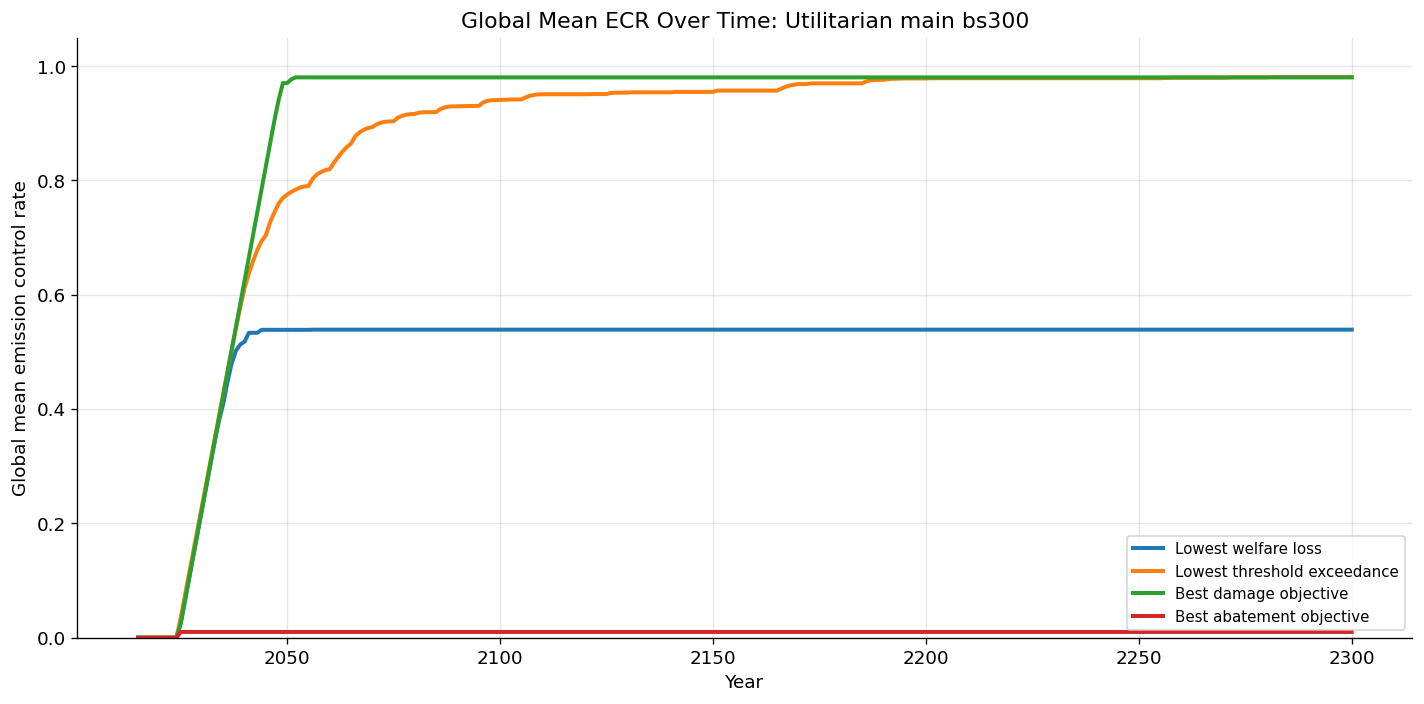

In [7]:
# ── Plot 3: global mean ECR over time, four policies, utilitarian bs300 ───────
fig, ax = plt.subplots(figsize=(12, 6))

for label, result in util_four.items():
    ax.plot(years, mean_global_ecr(result["ecr"]), linewidth=2.4, label=label)

ax.set_title("Global Mean ECR Over Time: Utilitarian main bs300")
ax.set_xlabel("Year")
ax.set_ylabel("Global mean emission control rate")
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "ecr_4_policies_utilitarian_main_bs300.png"), dpi=150)
plt.show()

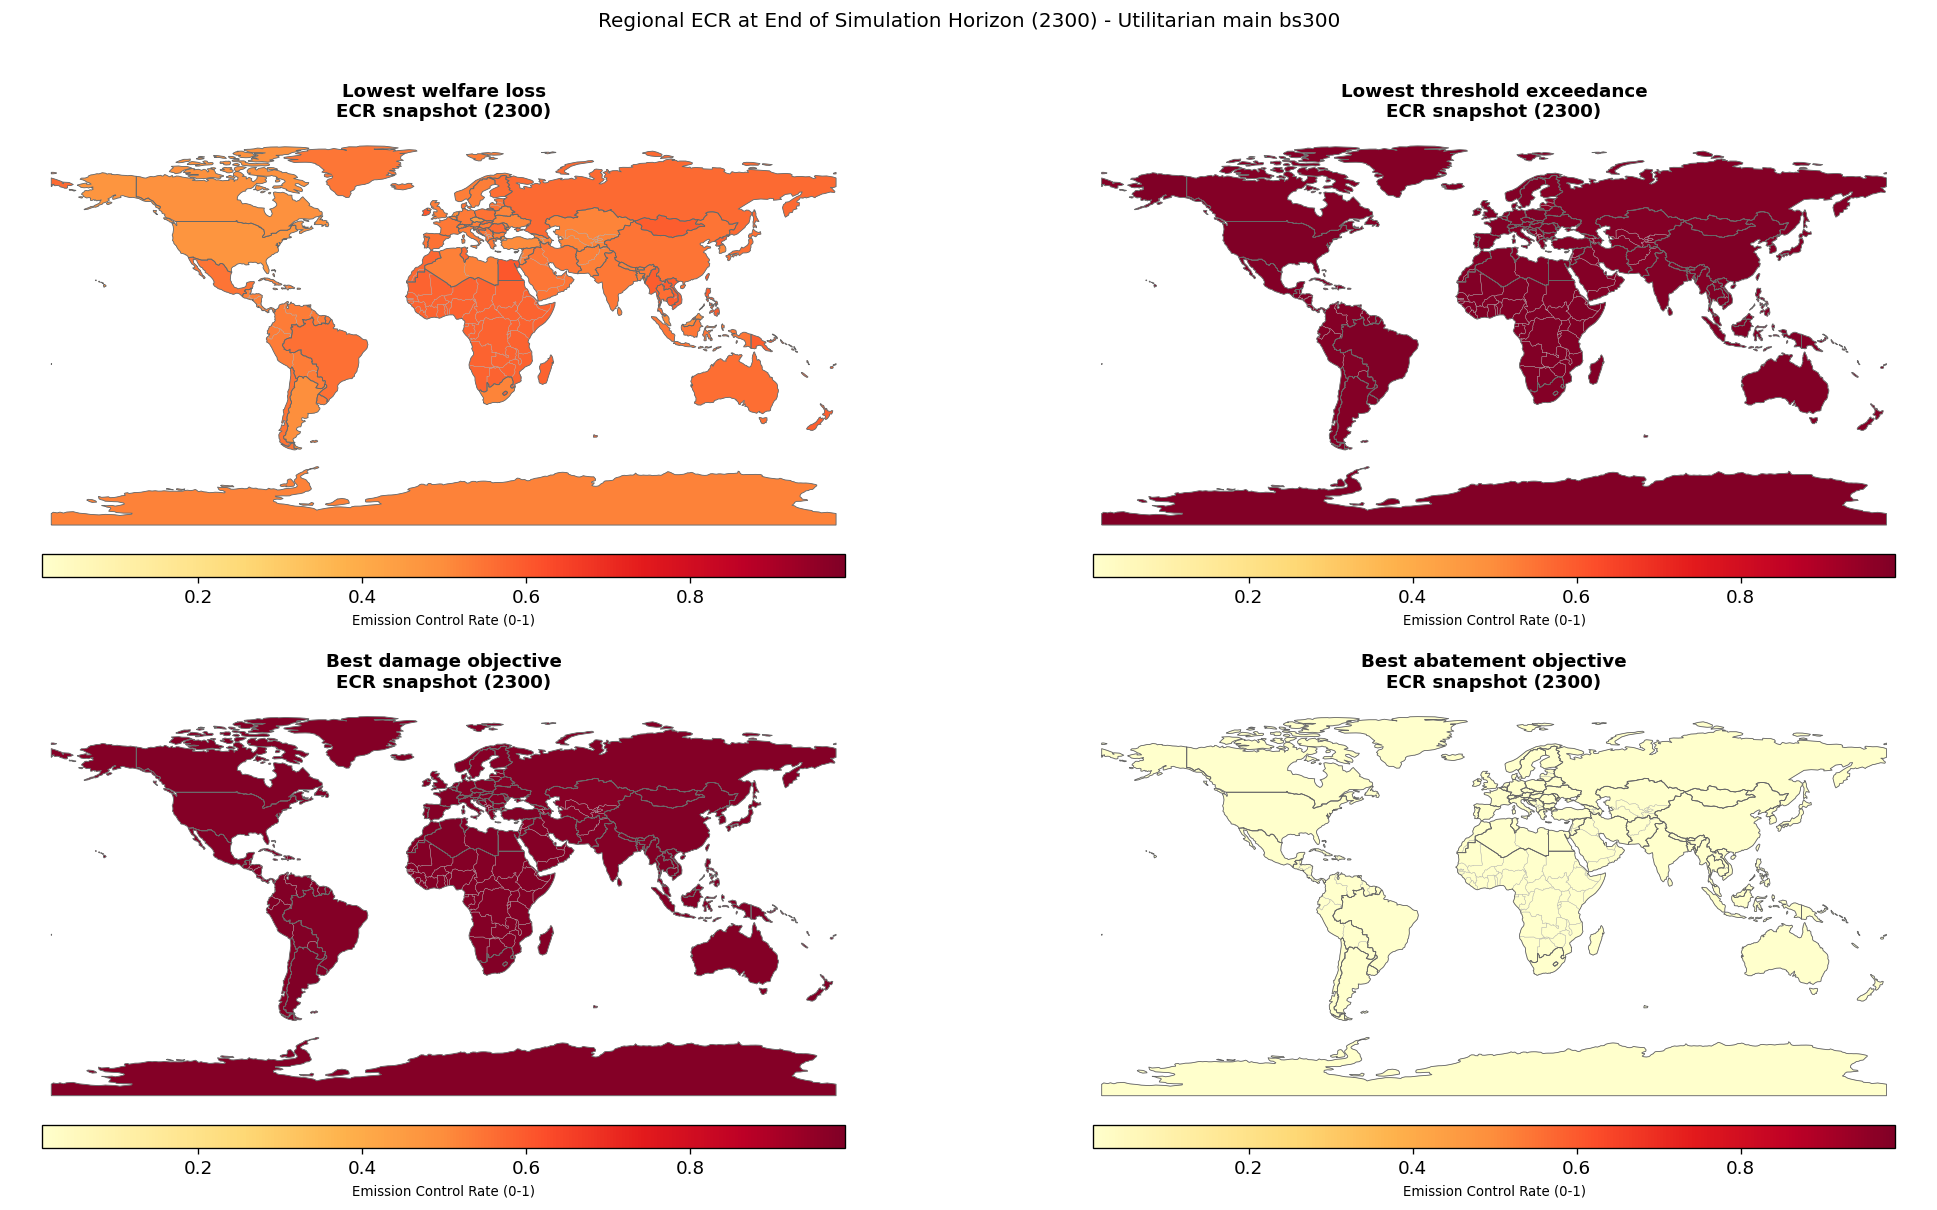

In [8]:
# ── Plot 4: regional ECR heatmap at end of horizon, utilitarian bs300 ─────────
rice50_path = os.path.join(JUSTICE_ROOT, "data", "input", "rice50_regions_dict.json")
with open(rice50_path) as fh:
    rice50_dict = json.load(fh)

iso_to_rice50 = {
    iso: region
    for region, isos in rice50_dict.items()
    for iso in isos
}

name_fallback = {
    "France": "fra",
    "Norway": "nor",
    "Kosovo": "oeu",
    "N. Cyprus": "tur",
    "Somaliland": "rsaf",
}

t_end = N_TIMESTEPS - 1
snap_year = int(years[t_end])

ecr_end = {
    label: {REGION_LIST[i]: result["ecr"][i, t_end] for i in range(N_REGIONS)}
    for label, result in util_four.items()
}

pyogrio_path = pathlib.Path(importlib.util.find_spec("pyogrio").origin).parent
ne_shp = str(pyogrio_path / "tests" / "fixtures" / "naturalearth_lowres" / "naturalearth_lowres.shp")

world = gpd.read_file(ne_shp)
world["rice50"] = world["iso_a3"].map(iso_to_rice50)
missing = world["rice50"].isna()
world.loc[missing, "rice50"] = world.loc[missing, "name"].map(name_fallback)

for label, region_ecr in ecr_end.items():
    world[f"ecr_{label}"] = world["rice50"].map(region_ecr)

ecr_cols = [f"ecr_{label}" for label in ecr_end]
regions_gdf = (
    world[world["rice50"].notna()]
    .dissolve(by="rice50", aggfunc="first")
    .reset_index()
)[["rice50", "geometry"] + ecr_cols]

regions_gdf = gpd.GeoDataFrame(regions_gdf, geometry="geometry", crs=world.crs)

panel_specs = [(f"ecr_{label}", f"{label}\nECR snapshot ({snap_year})") for label in ecr_end]
all_vals = pd.concat([regions_gdf[col].dropna() for col, _ in panel_specs])

cmap = plt.cm.YlOrRd
norm = mcolors.Normalize(vmin=all_vals.min(), vmax=all_vals.max())

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()

for ax, (col, title) in zip(axes, panel_specs):
    world.plot(ax=ax, color="0.88")
    world.boundary.plot(ax=ax, color="0.7", linewidth=0.2)

    regions_gdf.plot(
        ax=ax,
        color=[cmap(norm(v)) if pd.notna(v) else "0.88" for v in regions_gdf[col]],
    )
    regions_gdf.boundary.plot(ax=ax, color="0.4", linewidth=0.5)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, orientation="horizontal", pad=0.02, shrink=0.75, aspect=35)
    cbar.set_label("Emission Control Rate (0-1)", fontsize=8)

    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_axis_off()

fig.suptitle(
    f"Regional ECR at End of Simulation Horizon ({snap_year}) - Utilitarian main bs300",
    fontsize=12,
    y=1.01,
)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "ecr_regional_map_utilitarian_main_bs300.png"), dpi=150, bbox_inches="tight")
plt.show()

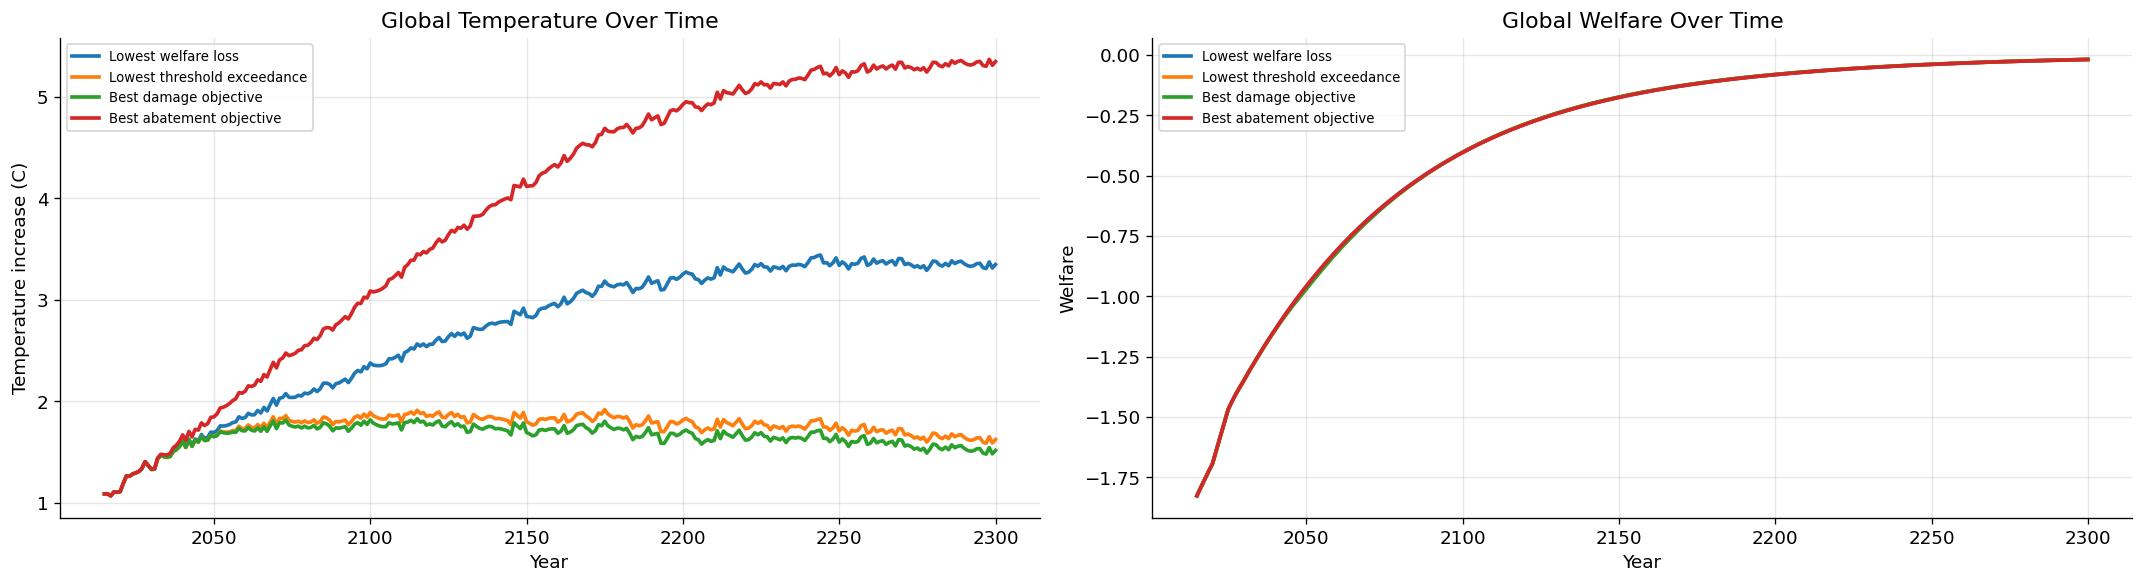

In [9]:
# ── Plot 5: global temperature and global welfare, four policies, util bs300 ──
fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharex=True)
ax_temp, ax_welfare = axes

for label, result in util_four.items():
    datasets = result["datasets"]
    ax_temp.plot(years, mean_global_temperature(datasets), linewidth=2.2, label=label)
    ax_welfare.plot(years, global_welfare(datasets), linewidth=2.2, label=label)

ax_temp.set_title("Global Temperature Over Time")
ax_temp.set_ylabel("Temperature increase (C)")

ax_welfare.set_title("Global Welfare Over Time")
ax_welfare.set_ylabel("Welfare")

for ax in axes:
    ax.set_xlabel("Year")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "temperature_welfare_4_policies_utilitarian_main_bs300.png"), dpi=150)
plt.show()

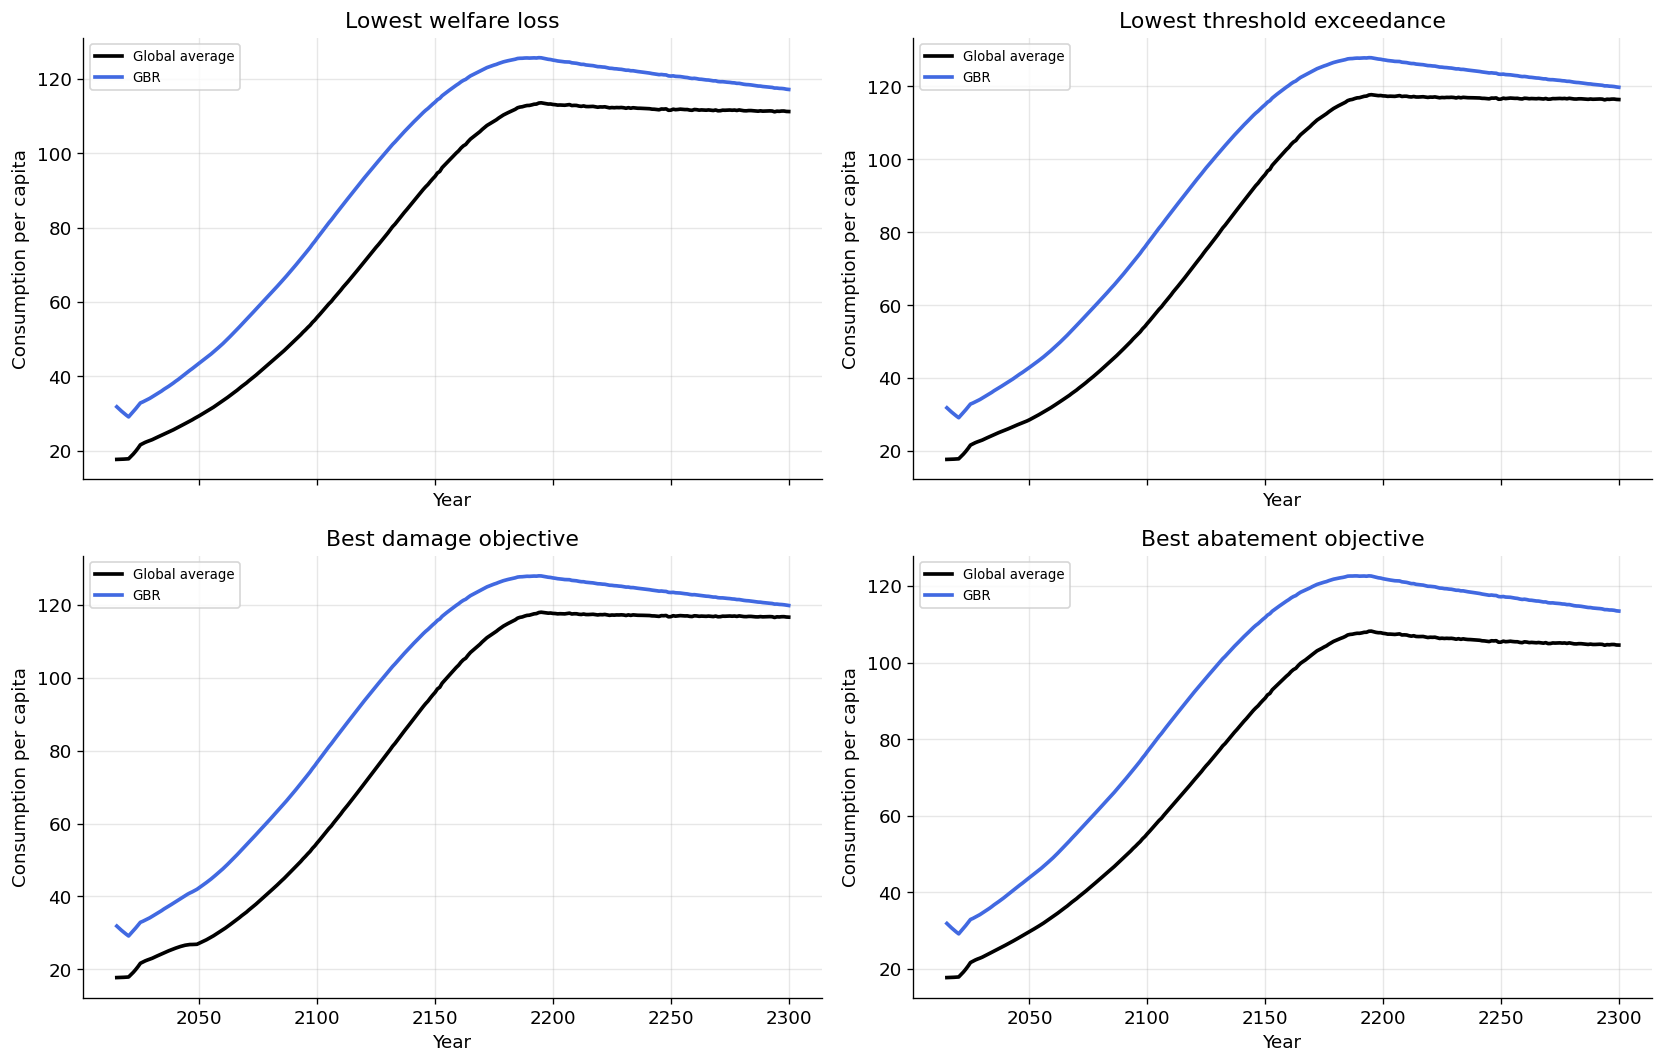

In [10]:
# ── Plot 6: consumption per capita, global average vs GBR, four policies ──────
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
axes = axes.flatten()

for ax, (label, result) in zip(axes, util_four.items()):
    datasets = result["datasets"]

    ax.plot(years, global_avg_consumption_per_capita(datasets), label="Global average", color="black", linewidth=2.2)
    ax.plot(years, gbr_consumption_per_capita(datasets), label="GBR", color="royalblue", linewidth=2.2)

    ax.set_title(label)
    ax.set_ylabel("Consumption per capita")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

for ax in axes:
    ax.set_xlabel("Year")

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "consumption_per_capita_global_vs_gbr_utilitarian_main_bs300.png"), dpi=150)
plt.show()

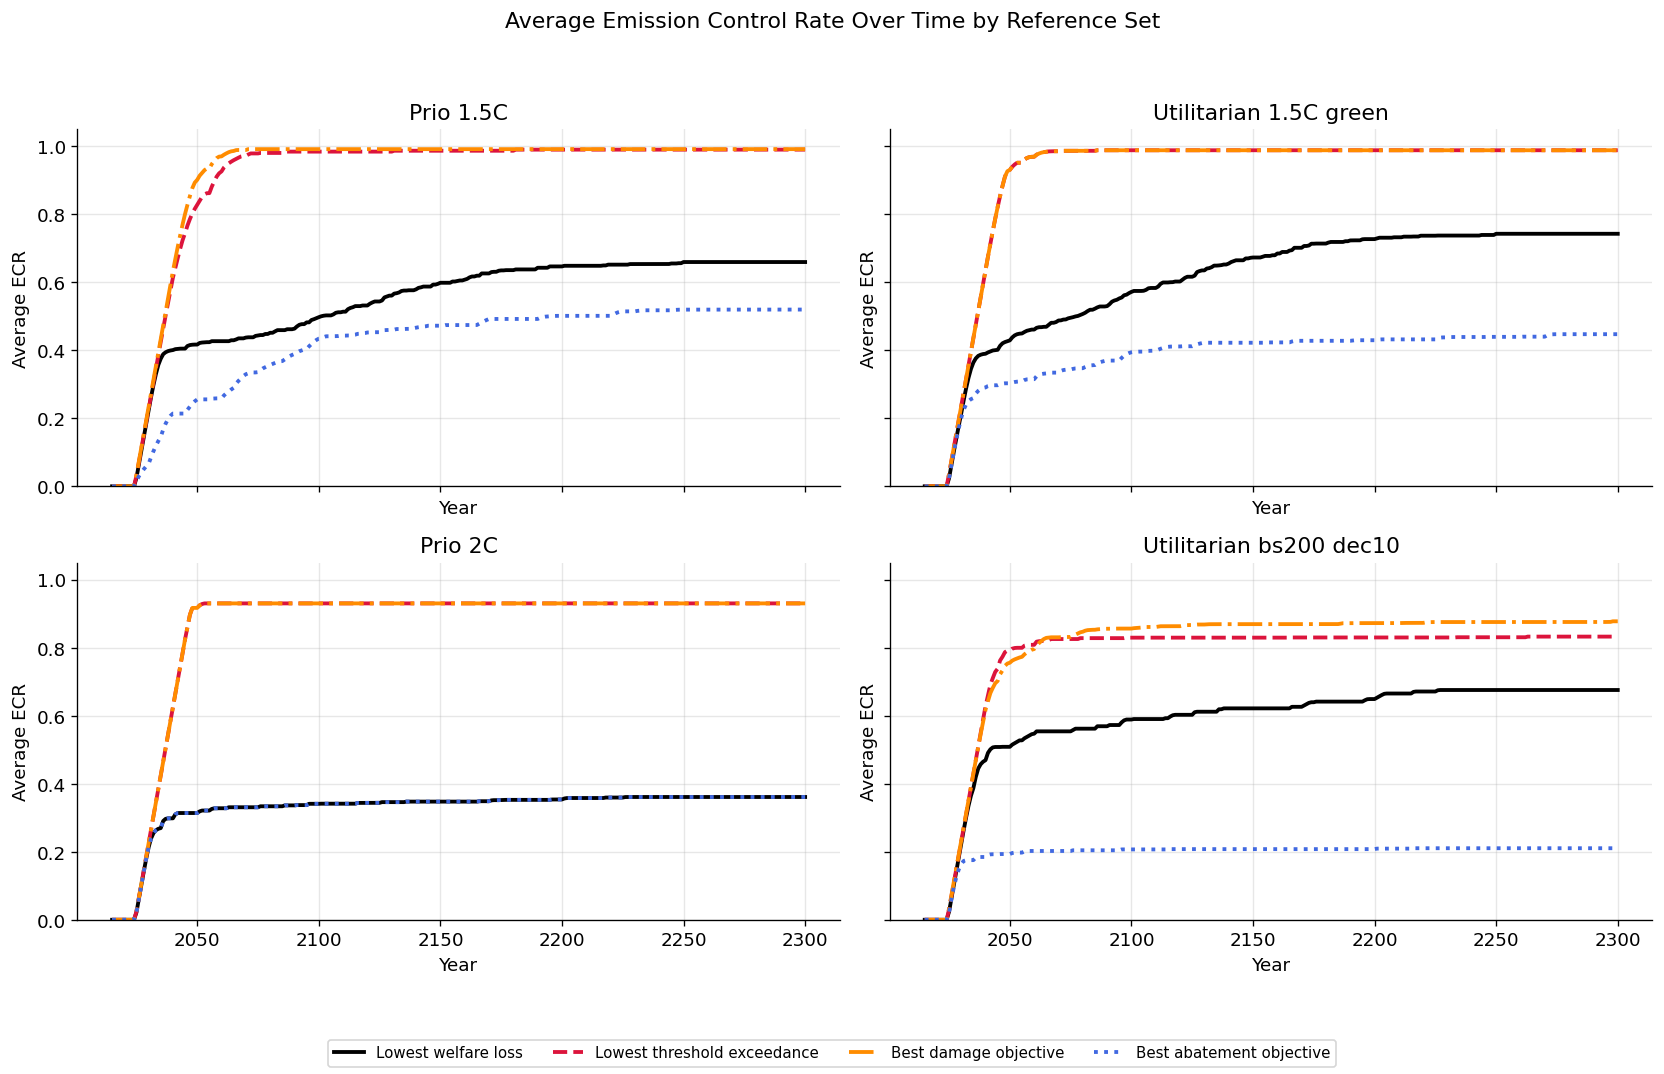

In [11]:
# ── Plot 7: average ECR over time by reference set, four policies each ────────
styles = {
    "Lowest welfare loss": "-",
    "Lowest threshold exceedance": "--",
    "Best damage objective": "-.",
    "Best abatement objective": ":",
}

colors = {
    "Lowest welfare loss": "black",
    "Lowest threshold exceedance": "crimson",
    "Best damage objective": "darkorange",
    "Best abatement objective": "royalblue",
}

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True, sharey=True)
axes = axes.flatten()

for ax, (ref_label, policy_results) in zip(axes, ecr_by_refset_results.items()):
    for policy_label, result in policy_results.items():
        ax.plot(
            years,
            mean_global_ecr(result["ecr"]),
            linewidth=2.3,
            linestyle=styles[policy_label],
            color=colors[policy_label],
            label=policy_label,
        )

    ax.set_title(ref_label)
    ax.set_xlabel("Year")
    ax.set_ylabel("Average ECR")
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, fontsize=9)

fig.suptitle("Average Emission Control Rate Over Time by Reference Set", y=0.98)
plt.tight_layout(rect=[0, 0.07, 1, 0.95])

plt.savefig(os.path.join(PLOTS_DIR, "ecr_over_time_four_policies_by_reference_set.png"), dpi=150)
plt.show()